# CIFAR-10 Image Classification Learning Project

# Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)


## Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Load the dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4577s 27us/step
Train shape: (50000, 32, 32, 3)
Test shape : (10000, 32, 32, 3)


## Visualize sample images

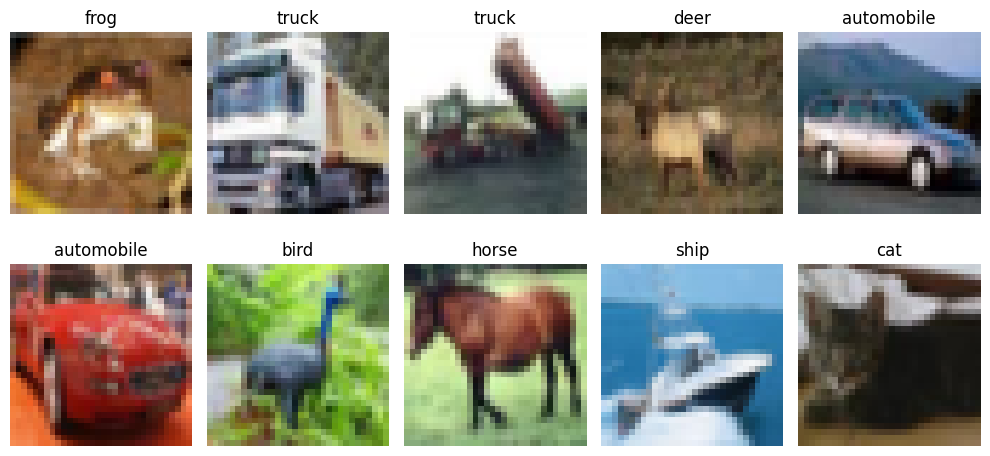

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Preprocessing

In [4]:
# normalize pixel values to 0-1
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# flatten for ANN (32*32*3 = 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized & flattened shape for ANN:", x_train_flat.shape)

Normalized & flattened shape for ANN: (50000, 3072)


## ANN Model
#### ANN just flattens the image so it loses spatial info that's why CNN is better but let's try ANN first

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

ann_history = ann_model.fit(x_train_flat, y_train,
                             epochs=10,
                             validation_split=0.1,
                             batch_size=64)

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print("ANN Test Accuracy:", ann_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2356 - loss: 2.0529 - val_accuracy: 0.3188 - val_loss: 1.9021
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.2844 - loss: 1.9343 - val_accuracy: 0.3248 - val_loss: 1.8585
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3026 - loss: 1.8922 - val_accuracy: 0.3438 - val_loss: 1.8300
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3091 - loss: 1.8768 - val_accuracy: 0.3436 - val_loss: 1.8391
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3191 - loss: 1.8537 - val_accuracy: 0.3682 - val_loss: 1.7838
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3232 - loss: 1.8427 - val_accuracy: 0.3580 - val_loss: 1.8187
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3336 - loss: 1.8305 - val_accuracy: 0.3700 - val_loss: 1.7703
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3334 - loss: 1.8195 - 

## CNN Model
#### CNN keeps spatial structure using conv layers, filters go 32 -> 64 -> 128

In [6]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_history = cnn_model.fit(x_train_norm, y_train,
                             epochs=10,
                             validation_split=0.1,
                             batch_size=64)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print("CNN Test Accuracy:", cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 194ms/step - accuracy: 0.4474 - loss: 1.5628 - val_accuracy: 0.4942 - val_loss: 1.4302
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 196ms/step - accuracy: 0.5909 - loss: 1.1534 - val_accuracy: 0.5772 - val_loss: 1.1860
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 197ms/step - accuracy: 0.6656 - loss: 0.9481 - val_accuracy: 0.5086 - val_loss: 1.9093
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 199ms/step - accuracy: 0.7161 - loss: 0.8157 - val_accuracy: 0.7076 - val_loss: 0.8516
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 197ms/step - accuracy: 0.7498 - loss: 0.7181 - val_accuracy: 0.6584 - val_loss: 1.0105
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 198ms/step - accuracy: 0.7808 - loss: 0.6219 - val_accuracy: 0.6726 - val_loss: 1.0279
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - accuracy: 0.8041 - loss: 0.5453 - val_accuracy: 0.7500 - val_loss: 0.7581
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 195ms/step - accuracy: 0.8288 -

## Plot ANN vs CNN validation accuracy

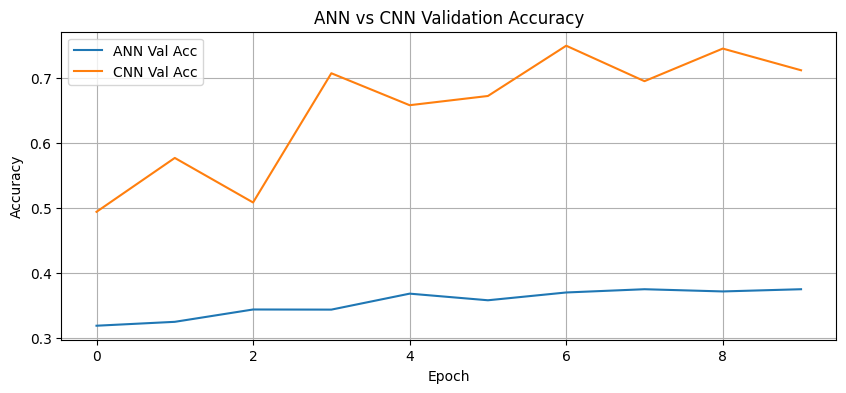

In [7]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Data augmentation CNN
#### adding random flips/rotations so model generalize better

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(x_train_norm, y_train,
                                 epochs=10,
                                 validation_split=0.1,
                                 batch_size=64)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 210ms/step - accuracy: 0.3651 - loss: 1.7697 - val_accuracy: 0.4946 - val_loss: 1.4219
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 208ms/step - accuracy: 0.4738 - loss: 1.4585 - val_accuracy: 0.5842 - val_loss: 1.1472
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 207ms/step - accuracy: 0.5275 - loss: 1.3199 - val_accuracy: 0.5898 - val_loss: 1.1873
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 210ms/step - accuracy: 0.5663 - loss: 1.2275 - val_accuracy: 0.5924 - val_loss: 1.1475
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 208ms/step - accuracy: 0.5970 - loss: 1.1550 - val_accuracy: 0.6082 - val_loss: 1.1243
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 208ms/step - accuracy: 0.6156 - loss: 1.1106 - val_accuracy: 0.5522 - val_loss: 1.3228
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 210ms/step - accuracy: 0.6338 - loss: 1.0613 - val_accuracy: 0.6492 - val_loss: 1.0507
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 211ms/step - accuracy: 0.6452 -

## Final comparison table

In [9]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [round(ann_test_acc, 4),
                      round(cnn_test_acc, 4),
                      round(aug_test_acc, 4)]
})
print(comparison)
comparison

                Model  Test Accuracy
0                 ANN         0.3926
1                 CNN         0.7074
2  CNN + Augmentation         0.6566


,Model,Test Accuracy
0,ANN,0.3926
1,CNN,0.7074
2,CNN + Augmentation,0.6566


## Student Tasks

### Task 1: increase ANN layers and see what happens

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.1953 - loss: 2.1134 - val_accuracy: 0.2794 - val_loss: 1.9777
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - accuracy: 0.2606 - loss: 1.9700 - val_accuracy: 0.3202 - val_loss: 1.8713
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.2830 - loss: 1.9260 - val_accuracy: 0.3158 - val_loss: 1.8842
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.2908 - loss: 1.9063 - val_accuracy: 0.3342 - val_loss: 1.8493
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.2984 - loss: 1.8863 - val_accuracy: 0.3452 - val_loss: 1.8340
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.3088 - loss: 1.8681 - val_accuracy: 0.3538 - val_loss: 1.8261
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3135 - loss: 1.8536 - val_accuracy: 0.3352 - val_loss: 1.8615
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3182 - loss: 1.8460 - 

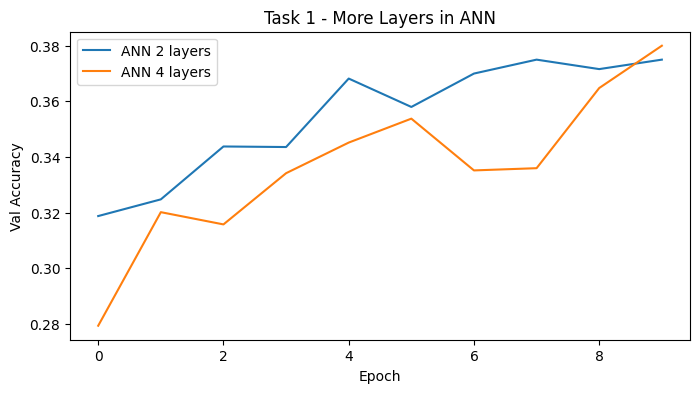

In [10]:
deep_ann = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

deep_ann_history = deep_ann.fit(x_train_flat, y_train,
                                 epochs=10,
                                 validation_split=0.1,
                                 batch_size=64)

_, deep_ann_acc = deep_ann.evaluate(x_test_flat, y_test, verbose=0)
print("Deep ANN accuracy:", deep_ann_acc)
print("Baseline ANN accuracy:", ann_test_acc)

plt.figure(figsize=(8,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN 2 layers')
plt.plot(deep_ann_history.history['val_accuracy'], label='ANN 4 layers')
plt.title("Task 1 - More Layers in ANN")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

### Task 2: CNN filters 32->64->128 (already done above in CNN Model) just printing to confirm

In [11]:
print("Task 2 - CNN filter sizes used: 32 -> 64 -> 128")
print("CNN test accuracy:", cnn_test_acc)

Task 2 - CNN filter sizes used: 32 -> 64 -> 128
CNN test accuracy: 0.7074000239372253


### Task 3: increase epochs to 20

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 203ms/step - accuracy: 0.4496 - loss: 1.5607 - val_accuracy: 0.5576 - val_loss: 1.2780
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.6042 - loss: 1.1250 - val_accuracy: 0.5866 - val_loss: 1.1854
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.6758 - loss: 0.9296 - val_accuracy: 0.6062 - val_loss: 1.2236
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 199ms/step - accuracy: 0.7243 - loss: 0.7965 - val_accuracy: 0.6908 - val_loss: 0.8847
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.7582 - loss: 0.6914 - val_accuracy: 0.7062 - val_loss: 0.8883
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 199ms/step - accuracy: 0.7902 - loss: 0.5998 - val_accuracy: 0.6106 - val_loss: 1.3878
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 202ms/step - accuracy: 0.8151 - loss: 0.5240 - val_accuracy: 0.7282 - val_loss: 0.8506
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 202ms/step - accuracy: 0.8400 -

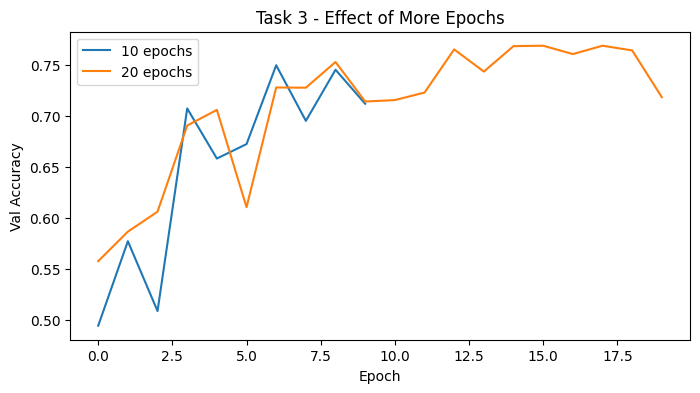

In [12]:
cnn_20 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

cnn_20_history = cnn_20.fit(x_train_norm, y_train,
                              epochs=20,
                              validation_split=0.1,
                              batch_size=64)

_, cnn_20_acc = cnn_20.evaluate(x_test_norm, y_test, verbose=0)
print("CNN 20 epochs accuracy:", cnn_20_acc)

plt.figure(figsize=(8,4))
plt.plot(cnn_history.history['val_accuracy'], label='10 epochs')
plt.plot(cnn_20_history.history['val_accuracy'], label='20 epochs')
plt.title("Task 3 - Effect of More Epochs")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

### Task 4: add early stopping

In [13]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=3,
                              restore_best_weights=True, verbose=1)

cnn_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

cnn_es_history = cnn_es.fit(x_train_norm, y_train,
                              epochs=50,
                              validation_split=0.1,
                              batch_size=64,
                              callbacks=[es])

_, cnn_es_acc = cnn_es.evaluate(x_test_norm, y_test, verbose=0)
stopped_at = len(cnn_es_history.history['val_accuracy'])
print(f"early stopping kicked in at epoch {stopped_at}")
print("accuracy:", cnn_es_acc)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 194ms/step - accuracy: 0.4300 - loss: 1.5995 - val_accuracy: 0.5014 - val_loss: 1.3806
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 198ms/step - accuracy: 0.5864 - loss: 1.1679 - val_accuracy: 0.5494 - val_loss: 1.3257
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 196ms/step - accuracy: 0.6650 - loss: 0.9549 - val_accuracy: 0.6190 - val_loss: 1.1160
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - accuracy: 0.7144 - loss: 0.8211 - val_accuracy: 0.6860 - val_loss: 0.9056
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 207ms/step - accuracy: 0.7502 - loss: 0.7126 - val_accuracy: 0.7272 - val_loss: 0.8115
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 196ms/step - accuracy: 0.7813 - loss: 0.6167 - val_accuracy: 0.7274 - val_loss: 0.8254
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 193ms/step - accuracy: 0.8116 - loss: 0.5372 - val_accuracy: 0.7206 - val_loss: 0.8551
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 196ms/step - accuracy: 0.8370 -

### Task 5: data augmentation (already trained above as aug_cnn_model)

In [14]:
print("Task 5 - Augmented CNN accuracy:", aug_test_acc)

Task 5 - Augmented CNN accuracy: 0.6565999984741211


## Summary of all tasks

In [15]:
final = pd.DataFrame({
    "Model": [
        "Baseline ANN",
        "Task1 - Deep ANN",
        "Task2 - CNN 32->64->128",
        "Task3 - CNN 20 epochs",
        "Task4 - CNN EarlyStopping",
        "Task5 - CNN + Augmentation"
    ],
    "Test Accuracy": [
        round(ann_test_acc, 4),
        round(deep_ann_acc, 4),
        round(cnn_test_acc, 4),
        round(cnn_20_acc, 4),
        round(cnn_es_acc, 4),
        round(aug_test_acc, 4)
    ]
})

print(final)
final

                        Model  Test Accuracy
0                Baseline ANN         0.3926
1            Task1 - Deep ANN         0.3794
2     Task2 - CNN 32->64->128         0.7074
3       Task3 - CNN 20 epochs         0.7047
4   Task4 - CNN EarlyStopping         0.7071
5  Task5 - CNN + Augmentation         0.6566


,Model,Test Accuracy
0,Baseline ANN,0.3926
1,Task1 - Deep ANN,0.3794
2,Task2 - CNN 32->64->128,0.7074
3,Task3 - CNN 20 epochs,0.7047
4,Task4 - CNN EarlyStopping,0.7071
5,Task5 - CNN + Augmentation,0.6566
